# Image Compression with the Singular Value Decomposition (SVD)

The Singular Value Decomposition (SVD) is a matrix factorization technique that expresses any matrix A as the product of three matrices:

$A =  U \Sigma V^T$
 
Where:

- U: a matrix of left singular vectors (captures row-based patterns),

- $\Sigma$ : a diagonal matrix of singular values (captures the strength of each pattern),

- $V^T$: a matrix of right singular vectors (captures column-based patterns).

Compression then works following these steps:

#### Decompose the image matrix into U, $\Sigma$, and $V^T$

For grayscale images, each pixel intensity can be represented in a 2D matrix.

#### Keep only the top k singular values and corresponding vectors

This step reduces the dimensionality by discarding less important components (smaller singular values).

#### Reconstruct the image using the truncated matrices:

$A_k =  U_k \Sigma_k V^T_k$
 
The higher the k, the closer the reconstruction is to the original image.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from sklearn.decomposition import TruncatedSVD

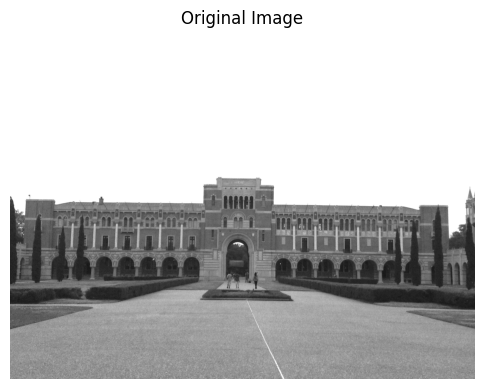

In [21]:
# Load image (grayscale for simplicity)
url = 'https://upload.wikimedia.org/wikipedia/commons/c/ce/Rice_University_Sally_Port.jpg'
img = io.imread(url, as_gray=True)

plt.figure(figsize=(6, 6))
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [22]:
def svd_reconstruct(U, S, VT, k):
    """
    Reconstruct the image using the top k singular values.
    """
    S_k = np.diag(S[:k])
    U_k = U[:, :k]
    VT_k = VT[:k, :]
    return np.dot(U_k, np.dot(S_k, VT_k))

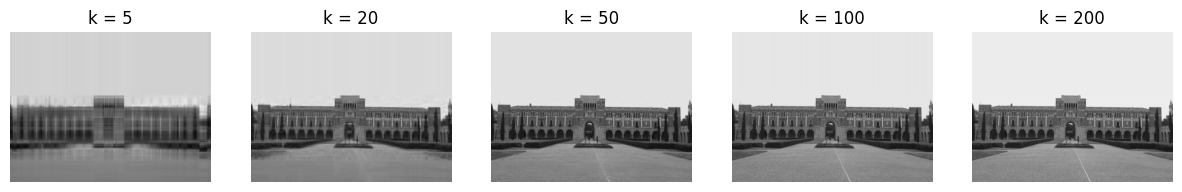

In [23]:
#Perform analysis and plot
U, S, VT = np.linalg.svd(img, full_matrices=False)
ks = [5, 20, 50, 100, 200]

fig, axes = plt.subplots(1, len(ks), figsize=(15, 5))
for i, k in enumerate(ks):
    compressed_img = svd_reconstruct(U, S, VT, k)
    axes[i].imshow(compressed_img, cmap='gray')
    axes[i].set_title(f'k = {k}')
    axes[i].axis('off')
plt.show()

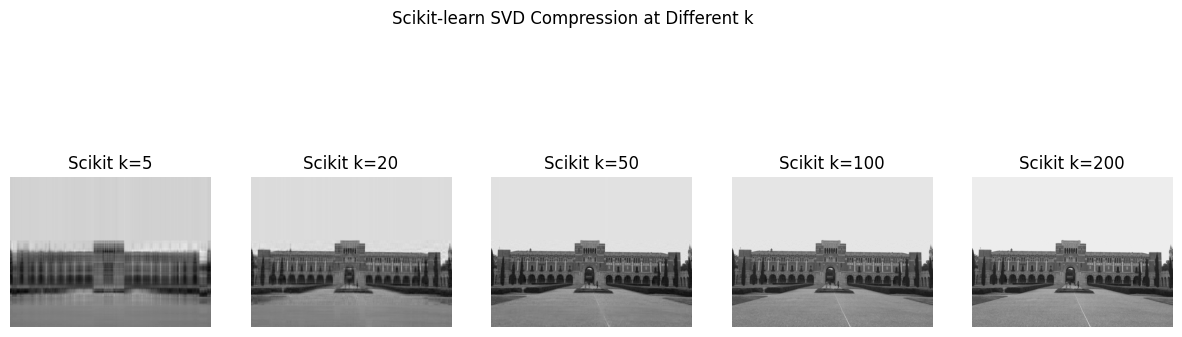

In [26]:
#Sklearn results for comparison
ks = [5, 20, 50, 100, 200]

fig, axes = plt.subplots(1, len(ks), figsize=(15, 5))

for i, k in enumerate(ks):
    # Initialize TruncatedSVD for current k
    svd_sklearn = TruncatedSVD(n_components=k)
    
    # Fit and transform
    U_sklearn = svd_sklearn.fit_transform(img)
    VT_sklearn = svd_sklearn.components_
    
    # Reconstruct the image
    img_reconstructed_sklearn = np.dot(U_sklearn, VT_sklearn)
    
    # Plot
    axes[i].imshow(img_reconstructed_sklearn, cmap='gray')
    axes[i].set_title(f'Scikit k={k}')
    axes[i].axis('off')

plt.suptitle('Scikit-learn SVD Compression at Different k')
plt.show()

In this notebook, we compressed a grayscale image of the Rice University Sallyport using both a custom Singular Value Decomposition (SVD) implementation and Scikit-learn’s TruncatedSVD. Both seem to have similar quality, at least at first glance.

We tested multiple values of k (the number of singular values/components kept) to observe how compression quality changes as more singular values are retained.

Custom SVD Results:
- Low k (e.g., 5, 20):
The compressed images showed significant loss of detail and appeared heavily blurred or blocky. However, the main structure of the image was still faintly recognizable, demonstrating that even a handful of singular values capture some basic information.

- Medium k (50, 100):
Visual clarity improved noticeably. The overall shape and finer architectural details become clearer, reflecting how additional singular values contribute more nuanced information.

- High k (200):
The reconstructed image was nearly identical to the original, with minimal visual difference. At this point, the majority of the original data had been retained, and increasing k is not necessarily advantageous.

